<a href="https://colab.research.google.com/github/diegolagreca/AltoroJ/blob/AltoroJ-3.2/PyEA_Proyecto_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="font-family: serif; line-height: 1.6; text-align: justify;">

# <center>Tarea 1 de Probabilidad y Estadística aplicada</center>

El objetivo de esta tarea es simular una variable aleatoria con distribución discreta y comparar sus resultados con la distribución uniforme en el intervalo $[0,1]$.

## Parte 1

Consideraremos el siguiente experimento aleatorio, se lanzan 10 monedas equilibradas de forma independiente. Para $i = 1,2,\ldots,10$ definimos las variables aleatorias

$$
M_i=
\begin{cases}
1 & \text{si la moneda } i \text{ sale cara} \\
0 & \text{si la moneda } i \text{ sale número}
\end{cases}
$$

Luego definimos la variable aleatoria

$$
X=\sum_{i=1}^{10}\frac{M_i}{2^i}
$$

**Se pide:**

1. ¿Cuál es la distribución de las variables ${M_i}$?
2. Demuestre que todos los valores del recorrido de \(X\) están en el intervalo $[0,1]$.
3. Escriba una función en Python que calcule el valor de \(X\) a partir de los resultados de las tiradas de las 10 monedas.
4. Utilice Python para calcular la cantidad de elementos en el recorrido de \(X\). Compare el resultado con la cantidad de formas distintas en que se pueden tirar 10 monedas.
5. Hallar la función de probabilidad de masa de la variable aleatoria $X$.
6. Hallar la esperanza y la varianza de $X$.
7. Buscar información sobre la distribución uniforme continua en el intervalo $[0,1]$. En particular encuentre el valor de su esperanza y su varianza.
8. Utilice Python para comprobar que si se usan más de 10 monedas, los nuevos valores de $E(X)$ y $\mathrm{Var}(X)$ se aproximan a la esperanza y varianza de la distribución uniforme continua en $[0,1]$.

</div>


**1. ¿Cuál es la distribución de las variables ${M_i}$?**

Para cada $i \in \{1,\dots,10\}$, definimos la variable aleatoria $M_i$ por

$$
M_i =
\begin{cases}
1, & \text{si la } i\text{-ésima moneda sale cara},\\
0, & \text{si la } i\text{-ésima moneda sale número}.
\end{cases}
$$

Como las monedas son equilibradas, se tiene que

$$
\mathbb{P}(M_i = 1) = \frac{1}{2},
\qquad
\mathbb{P}(M_i = 0) = \frac{1}{2}.
$$

Por lo tanto, para todo $i \in \{1,\dots,10\}$,

$$
M_i \sim \operatorname{Bernoulli}\!\left(\frac{1}{2}\right).
$$


**2. Demuestre que todos los valores del recorrido de \(X\) están en el intervalo $[0,1]$.**

Siguiendo la idea de Devore de identificar el intervalo que contiene los valores posibles de una variable aleatoria continua, demostraremos que todo valor posible de $X$ queda contenido en $[0,1]$.

Para cada $i \in \{1,\dots,10\}$, se tiene que $M_i \in \{0,1\}$. En consecuencia,

$$
0 \le M_i \le 1
\qquad \Longrightarrow \qquad
0 \le \frac{M_i}{2^i} \le \frac{1}{2^i}.
$$

Sumando estas desigualdades para $i=1,\dots,10$, obtenemos

$$
0 \le \sum_{i=1}^{10}\frac{M_i}{2^i} \le \sum_{i=1}^{10}\frac{1}{2^i}.
$$

Como

$$
X=\sum_{i=1}^{10}\frac{M_i}{2^i},
$$

se sigue que

$$
0 \le X \le \sum_{i=1}^{10}\frac{1}{2^i}.
$$

Ahora bien, la suma del lado derecho es una serie geométrica finita de razón $\frac{1}{2}$, por lo que

$$
\sum_{i=1}^{10}\frac{1}{2^i}
=
\frac{\frac{1}{2}\left(1-\left(\frac{1}{2}\right)^{10}\right)}{1-\frac{1}{2}}
=
1-\frac{1}{2^{10}}
<1.
$$

Por lo tanto,

$$
0 \le X \le 1-\frac{1}{2^{10}} < 1.
$$

En consecuencia, todo valor del recorrido de $X$ pertenece al intervalo $[0,1]$. Es decir,

$$
\operatorname{Rec}(X)\subseteq [0,1].
$$

aunque $X$ es una variable aleatoria discreta, este resultado muestra que todos sus valores posibles quedan contenidos en el intervalo $[0,1]$, lo cual será relevante al compararla más adelante con la distribución uniforme continua sobre ese mismo intervalo.


**3. Escriba una función en Python que calcule el valor de \(X\) a partir de los resultados de las tiradas de las 10 monedas.**

De acuerdo con la definición

$$
X=\sum_{i=1}^{10}\frac{M_i}{2^i},
$$

implementamos una función que recibe los resultados de las 10 tiradas, donde cada $M_i \in \{0,1\}$, y devuelve el valor correspondiente de $X$.


In [ ]:
def calcular_X(resultados):
    """
    Calcula X = sum_{i=1}^{10} M_i / 2^i
    a partir de los resultados de 10 tiradas.
    """
    if len(resultados) != 10:
        raise ValueError("Se deben ingresar exactamente 10 resultados.")

    if any(m not in (0, 1) for m in resultados):
        raise ValueError("Cada resultado debe ser 0 o 1.")

    return sum(m / (2 ** i) for i, m in enumerate(resultados, start=1))


# Ejemplo de uso
tiradas = [1, 0, 1, 1, 0, 0, 1, 0, 1, 0]
X = calcular_X(tiradas)

print("El valor de X es:", X)


El valor de X es: 0.697265625


**4. Utilice Python para calcular la cantidad de elementos en el recorrido de (X). Compare el resultado con la cantidad de formas distintas en que se pueden tirar 10 monedas.**

Cada elección de $(M_1,\dots,M_{10}) \in \{0,1\}^{10}$ determina un valor de

$$
X=\sum_{i=1}^{10}\frac{M_i}{2^i}.
$$

Para calcular la cantidad de elementos del recorrido de $X$, generamos con Python todas las secuencias posibles de 10 tiradas, calculamos el valor correspondiente de $X$ en cada caso y contamos cuántos valores distintos se obtienen. Luego comparamos este número con la cantidad total de formas distintas de tirar 10 monedas, que es

$$
2^{10}=1024.
$$


In [ ]:
from itertools import product
from fractions import Fraction

def calcular_X_exacto(resultados):
    if len(resultados) != 10:
        raise ValueError("Se deben ingresar exactamente 10 resultados.")
    if any(m not in (0, 1) for m in resultados):
        raise ValueError("Cada resultado debe ser 0 o 1.")

    return sum(Fraction(m, 2**i) for i, m in enumerate(resultados, start=1))

# Generar todas las formas posibles de tirar 10 monedas
todas_las_tiradas = list(product([0, 1], repeat=10))

# Calcular todos los valores posibles de X
recorrido_X = {calcular_X_exacto(tiradas) for tiradas in todas_las_tiradas}

# Cantidades a comparar
cantidad_recorrido = len(recorrido_X)
cantidad_formas = len(todas_las_tiradas)

print("Cantidad de elementos en el recorrido de X:", cantidad_recorrido)
print("Cantidad de formas distintas de tirar 10 monedas:", cantidad_formas)

if cantidad_recorrido == cantidad_formas:
    print("Conclusión: ambas cantidades coinciden.")
else:
    print("Conclusión: las cantidades no coinciden.")


Cantidad de elementos en el recorrido de X: 1024
Cantidad de formas distintas de tirar 10 monedas: 1024
Conclusión: ambas cantidades coinciden.


**5. Hallar la función de probabilidad de masa de la variable aleatoria $X$.**

Para hallar la función de probabilidad de masa de $X$, observamos que cada sucesión $(M_1,\dots,M_{10}) \in \{0,1\}^{10}$ determina un único valor de

$$
X=\sum_{i=1}^{10}\frac{M_i}{2^i}.
$$

Además,

$$
X=\frac{M_1 2^9 + M_2 2^8 + \cdots + M_{10}}{2^{10}}.
$$

Por lo tanto, los valores posibles de $X$ son de la forma

$$
\frac{k}{2^{10}}, \qquad k=0,1,\dots,2^{10}-1.
$$

Como las variables $M_1,\dots,M_{10}$ son independientes y cada una satisface

$$
\mathbb{P}(M_i=0)=\mathbb{P}(M_i=1)=\frac{1}{2},
$$

se sigue que para cualquier elección $(m_1,\dots,m_{10}) \in \{0,1\}^{10}$,

$$
\mathbb{P}(M_1=m_1,\dots,M_{10}=m_{10})=\left(\frac{1}{2}\right)^{10}.
$$

Dado que a cada valor posible de $X$ le corresponde exactamente una sucesión $(m_1,\dots,m_{10})$, concluimos que la función de probabilidad de masa de $X$ es

$$
p_X(x)=\mathbb{P}(X=x)=
\begin{cases}
\dfrac{1}{2^{10}}, & \text{si } x=\dfrac{k}{2^{10}}, \quad k=0,1,\dots,2^{10}-1, \\[2mm]
0, & \text{en otro caso.}
\end{cases}
$$

En consecuencia, $X$ tiene distribución uniforme discreta sobre su recorrido.



In [ ]:
from fractions import Fraction

def fmp_X(x):
    """
    Función de probabilidad de masa de X.
    Se recomienda ingresar x como Fraction para evitar errores de redondeo.
    """
    if isinstance(x, int):
        x = Fraction(x, 1)
    elif isinstance(x, float):
        x = Fraction(x).limit_denominator(2**10)
    elif not isinstance(x, Fraction):
        raise TypeError("x debe ser un entero, float o Fraction.")

    k = x * (2**10)

    if k.denominator == 1 and 0 <= k.numerator <= 2**10 - 1:
        return Fraction(1, 2**10)
    return Fraction(0, 1)

# Algunos ejemplos
print("P(X = 0) =", fmp_X(Fraction(0, 1)))
print("P(X = 1/2) =", fmp_X(Fraction(1, 2)))
print("P(X = 341/1024) =", fmp_X(Fraction(341, 1024)))
print("P(X = 1023/1024) =", fmp_X(Fraction(1023, 1024)))
print("P(X = 1) =", fmp_X(Fraction(1, 1)))


P(X = 0) = 1/1024
P(X = 1/2) = 1/1024
P(X = 341/1024) = 1/1024
P(X = 1023/1024) = 1/1024
P(X = 1) = 0


**6. Hallar la esperanza y la varianza de $X$.**

Usando la linealidad del valor esperado y la independencia de las variables $M_1,\dots,M_{10}$, calculamos la esperanza y la varianza de $X$.

Como

$$
X=\sum_{i=1}^{10}\frac{M_i}{2^i},
$$

y cada $M_i \sim \operatorname{Bernoulli}\!\left(\frac{1}{2}\right)$, se tiene que

$$
\mathbb{E}(M_i)=\frac{1}{2},
\qquad
\operatorname{Var}(M_i)=\frac{1}{2}\left(1-\frac{1}{2}\right)=\frac{1}{4}.
$$

Por la linealidad del valor esperado,

$$
\mathbb{E}(X)
=
\mathbb{E}\!\left(\sum_{i=1}^{10}\frac{M_i}{2^i}\right)
=
\sum_{i=1}^{10}\frac{1}{2^i}\,\mathbb{E}(M_i)
=
\sum_{i=1}^{10}\frac{1}{2^{i+1}}.
$$

Esta es una suma geométrica finita, de modo que

$$
\mathbb{E}(X)
=
\frac{1}{2}\sum_{i=1}^{10}\frac{1}{2^i}
=
\frac{1}{2}\left(1-\frac{1}{2^{10}}\right)
=
\frac{1023}{2048}.
$$

Además, como las variables $M_1,\dots,M_{10}$ son independientes,

$$
\operatorname{Var}(X)
=
\operatorname{Var}\!\left(\sum_{i=1}^{10}\frac{M_i}{2^i}\right)
=
\sum_{i=1}^{10}\operatorname{Var}\!\left(\frac{M_i}{2^i}\right)
=
\sum_{i=1}^{10}\frac{1}{4^i}\operatorname{Var}(M_i).
$$

Por lo tanto,

$$
\operatorname{Var}(X)
=
\sum_{i=1}^{10}\frac{1}{4^i}\cdot\frac{1}{4}
=
\sum_{i=1}^{10}\frac{1}{4^{i+1}}.
$$

Nuevamente, usando la fórmula de la suma geométrica,

$$
\operatorname{Var}(X)
=
\frac{1}{16}\cdot\frac{1-\left(\frac{1}{4}\right)^{10}}{1-\frac{1}{4}}
=
\frac{1}{12}\left(1-\frac{1}{4^{10}}\right)
=
\frac{1048575}{12582912}.
$$

En consecuencia,

$$
\mathbb{E}(X)=\frac{1023}{2048}\approx 0.49951171875,
\qquad
\operatorname{Var}(X)=\frac{1048575}{12582912}\approx 0.08333325386.
$$

Obsérvese que estos valores son muy cercanos a los de la distribución uniforme continua en $[0,1]$, cuya esperanza es $\frac{1}{2}$ y cuya varianza es $\frac{1}{12}$.


In [ ]:
from fractions import Fraction

E_X = sum(Fraction(1, 2**i) * Fraction(1, 2) for i in range(1, 11))
Var_X = sum((Fraction(1, 2**i) ** 2) * Fraction(1, 4) for i in range(1, 11))

print("E(X) =", E_X, "≈", float(E_X))
print("Var(X) =", Var_X, "≈", float(Var_X))


E(X) = 1023/2048 ≈ 0.49951171875
Var(X) = 349525/4194304 ≈ 0.08333325386047363


**7. Buscar información sobre la distribución uniforme continua en el intervalo $[0,1]$. En particular encuentre el valor de su esperanza y su varianza.**

Sea $U$ una variable aleatoria con distribución uniforme continua en el intervalo $[0,1]$. Entonces su función de densidad de probabilidad es

$$
f_U(x)=
\begin{cases}
1, & 0 \le x \le 1,\\
0, & \text{en otro caso}.
\end{cases}
$$

En consecuencia, su función de distribución acumulativa es

$$
F_U(x)=
\begin{cases}
0, & x<0,\\
x, & 0 \le x \le 1,\\
1, & x>1.
\end{cases}
$$

La esperanza de $U$ se calcula mediante

$$
\mathbb{E}(U)=\int_{-\infty}^{\infty} x f_U(x)\,dx
=\int_0^1 x\,dx
=
\left[\frac{x^2}{2}\right]_0^1
=
\frac{1}{2}.
$$

Para calcular la varianza, primero obtenemos

$$
\mathbb{E}(U^2)
=
\int_{-\infty}^{\infty} x^2 f_U(x)\,dx
=
\int_0^1 x^2\,dx
=
\left[\frac{x^3}{3}\right]_0^1
=
\frac{1}{3}.
$$

Por lo tanto,

$$
\operatorname{Var}(U)
=
\mathbb{E}(U^2)-\bigl(\mathbb{E}(U)\bigr)^2
=
\frac{1}{3}-\left(\frac{1}{2}\right)^2
=
\frac{1}{3}-\frac{1}{4}
=
\frac{1}{12}.
$$

En conclusión, si $U \sim \operatorname{Unif}[0,1]$, entonces

$$
\mathbb{E}(U)=\frac{1}{2},
\qquad
\operatorname{Var}(U)=\frac{1}{12}.
$$


In [ ]:
import sympy as sp

x = sp.symbols('x', real=True)

E_U = sp.integrate(x, (x, 0, 1))
E_U2 = sp.integrate(x**2, (x, 0, 1))
Var_U = sp.simplify(E_U2 - E_U**2)

print("E(U) =", E_U, "≈", float(E_U))
print("Var(U) =", Var_U, "≈", float(Var_U))


E(U) = 1/2 ≈ 0.5
Var(U) = 1/12 ≈ 0.08333333333333333


**8. Utilice Python para comprobar que si se usan más de 10 monedas, los nuevos valores de $E(X)$ y $\mathrm{Var}(X)$ se aproximan a la esperanza y varianza de la distribución uniforme continua en $[0,1]$.**

Para estudiar qué ocurre cuando se usan más de $10$ monedas, definimos, para cada $n \geq 1$,

$$
X_n=\sum_{i=1}^{n}\frac{M_i}{2^i},
$$

donde $M_1,\dots,M_n$ son variables aleatorias independientes con distribución $\operatorname{Bernoulli}\!\left(\frac{1}{2}\right)$.

De los incisos anteriores se obtiene que

$$
\mathbb{E}(X_n)=\frac{1}{2}\left(1-\frac{1}{2^n}\right),
\qquad
\operatorname{Var}(X_n)=\frac{1}{12}\left(1-\frac{1}{4^n}\right).
$$

Por lo tanto,

$$
\lim_{n\to\infty}\mathbb{E}(X_n)=\frac{1}{2},
\qquad
\lim_{n\to\infty}\operatorname{Var}(X_n)=\frac{1}{12}.
$$

Estos valores coinciden con la esperanza y la varianza de la distribución uniforme continua en $[0,1]$. A continuación, usamos Python para comprobar numéricamente esta convergencia con cinco cantidades distintas de monedas mayores que $10$.


,n,E(X_n),|E(X_n) - 1/2|,Var(X_n),|Var(X_n) - 1/12|
0,12,0.499878,1.220703e-04,0.083333,4.967054e-09
1,15,0.499985,1.525879e-05,0.083333,7.761021e-11
2,20,0.500000,4.768372e-07,0.083333,7.578660e-14
3,30,0.500000,4.656613e-10,0.083333,0.000000e+00
4,50,0.500000,4.440892e-16,0.083333,0.000000e+00


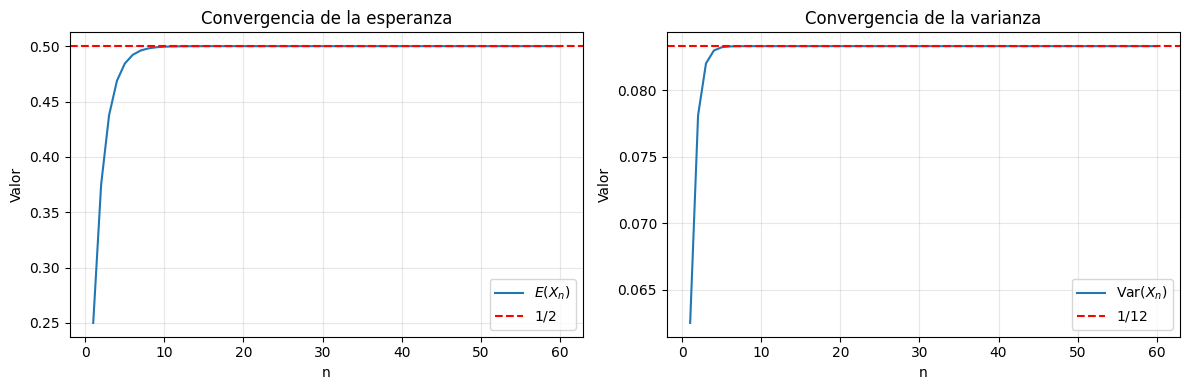

Conclusión:
A medida que n aumenta, E(X_n) se aproxima a 1/2 y Var(X_n) se aproxima a 1/12.
Estos son exactamente los valores de la distribución uniforme continua en [0,1].


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def esperanza_X(n):
    return 0.5 * (1 - 1 / (2**n))

def varianza_X(n):
    return (1/12) * (1 - 1 / (4**n))

valores_n = [12, 15, 20, 30, 50]
media_uniforme = 0.5
var_uniforme = 1/12

datos = []

for n in valores_n:
    ex = esperanza_X(n)
    vx = varianza_X(n)

    datos.append({
        "n": n,
        "E(X_n)": ex,
        "|E(X_n) - 1/2|": abs(ex - media_uniforme),
        "Var(X_n)": vx,
        "|Var(X_n) - 1/12|": abs(vx - var_uniforme),
    })

df = pd.DataFrame(datos)
display(df)

ns = np.arange(1, 61)
esperanzas = [esperanza_X(int(n)) for n in ns]
varianzas = [varianza_X(int(n)) for n in ns]

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(ns, esperanzas, label=r"$E(X_n)$")
plt.axhline(0.5, color="red", linestyle="--", label=r"$1/2$")
plt.xlabel("n")
plt.ylabel("Valor")
plt.title("Convergencia de la esperanza")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(ns, varianzas, label=r"$\mathrm{Var}(X_n)$")
plt.axhline(1/12, color="red", linestyle="--", label=r"$1/12$")
plt.xlabel("n")
plt.ylabel("Valor")
plt.title("Convergencia de la varianza")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Conclusión:")
print("A medida que n aumenta, E(X_n) se aproxima a 1/2 y Var(X_n) se aproxima a 1/12.")
print("Estos son exactamente los valores de la distribución uniforme continua en [0,1].")
